In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU,
    Bidirectional, GlobalMaxPooling1D,
    Dense, Dropout, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU,
    Bidirectional, GlobalMaxPooling1D,
    Dense, Dropout, Input, SpatialDropout1D  # أضفها هنا
)

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [45]:
# Increased vocabulary & sequence length for richer representation
MAX_FEATURES = 20000   # Vocabulary size  (was 10 000)
MAX_LEN      = 100     # Max review length (was 200)

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MAX_FEATURES)

print("Training samples:", len(x_train))
print("Testing samples:",  len(x_test))
print("Example encoded review:", x_train[0][:20])
print("Example label:", y_train[0])


Training samples: 25000
Testing samples: 25000
Example encoded review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Example label: 1


In [46]:
x_train_pad = pad_sequences(x_train, maxlen=MAX_LEN, padding='post', truncating='post')
x_test_pad  = pad_sequences(x_test,  maxlen=MAX_LEN, padding='post', truncating='post')

print("x_train shape:", x_train_pad.shape)
print("x_test shape:",  x_test_pad.shape)


x_train shape: (25000, 100)
x_test shape: (25000, 100)


In [47]:
word_index = imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(encoded_review):
    return " ".join(reverse_word_index.get(i, "?") for i in encoded_review)

print(decode_review(x_train[0])[:500])


<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would r


In [ ]:
EMBEDDING_DIM = 128
DROPOUT_RATE  = 0.3   # Reduced from 0.5 — less aggressive regularisation
def build_simple_rnn():

    inp = Input(shape=(MAX_LEN,))
    x = Embedding(MAX_FEATURES, 64)(inp)
    x = SpatialDropout1D(0.2)(x)

    # 2. الحل السحري: recurrent_initializer='identity'
    # هذا يجعل الـ RNN يبدأ كأنه "ذاكرة كاملة" تمرر المعلومات دون تغيير
    # 3. استخدام tanh للحفاظ على استقرار الأرقام ومنع الانفجار
    x = SimpleRNN(64,
                  activation='tanh',
                  recurrent_initializer='identity',
                  dropout=0.2)(x)

    x = Dense(32)(x)
    x = LeakyReLU(alpha=0.1)(x) # استخدام LeakyReLU هنا في الطبقات العادية آمن وممتاز

    out = Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)

    # 4. استخدام clipnorm=1.0 للسيطرة على التدرجات دون خنقها
    opt = Adam(learning_rate=1e-4, clipnorm=1.0)

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model


# ─────────────────────────────────────────────
#  Model 2 — Best LSTM
#  Bidirectional + recurrent_dropout fights overfitting
#  inside the recurrent cell itself
# ─────────────────────────────────────────────
def build_lstm():
    inp = Input(shape=(MAX_LEN,))
    x = Embedding(MAX_FEATURES, EMBEDDING_DIM)(inp)

    x = Bidirectional(LSTM(128, return_sequences=True,
                           dropout=0.2, recurrent_dropout=0.1))(x)
    x = Bidirectional(LSTM(64,  return_sequences=True,
                           dropout=0.2, recurrent_dropout=0.1))(x)
    x = GlobalMaxPooling1D()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(DROPOUT_RATE)(x)
    x = Dense(64,  activation='relu')(x)
    x = Dropout(0.2)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(Adam(1e-3), 'binary_crossentropy', metrics=['accuracy'])
    return model


# ─────────────────────────────────────────────
#  Model 3 — Best GRU
#  Same architecture as LSTM but GRU cells —
#  faster to train, similar accuracy
# ─────────────────────────────────────────────
def build_gru():
    inp = Input(shape=(MAX_LEN,))
    x = Embedding(MAX_FEATURES, EMBEDDING_DIM)(inp)

    x = Bidirectional(GRU(128, return_sequences=True,
                          dropout=0.2, recurrent_dropout=0.1))(x)
    x = Bidirectional(GRU(64,  return_sequences=True,
                          dropout=0.2, recurrent_dropout=0.1))(x)
    x = GlobalMaxPooling1D()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(DROPOUT_RATE)(x)
    x = Dense(64,  activation='relu')(x)
    x = Dropout(0.2)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(Adam(1e-3), 'binary_crossentropy', metrics=['accuracy'])
    return model


In [49]:
EPOCHS     = 15   # More room to converge (was 5)
BATCH_SIZE = 64   # Smaller batch → sharper gradients (was 128)

# Monitor val_accuracy (not val_loss) so we save the truly best checkpoint
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Halve the learning rate when improvement stalls
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


def train_model(model, model_name):
    print(f"================ Training {model_name} ================")
    history = model.fit(
        x_train_pad,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    return history


In [50]:
simple_rnn_model = build_simple_rnn()
lstm_model        = build_lstm()
gru_model         = build_gru()

history_rnn  = train_model(simple_rnn_model, "Simple RNN")
history_lstm = train_model(lstm_model,        "LSTM")
history_gru  = train_model(gru_model,         "GRU")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


================ Training Simple RNN ================
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.6538 - loss: 0.6163 - val_accuracy: 0.7558 - val_loss: 0.5012 - learning_rate: 1.0000e-04
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7864 - loss: 0.4643 - val_accuracy: 0.8004 - val_loss: 0.4336 - learning_rate: 1.0000e-04
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8367 - loss: 0.3787 - val_accuracy: 0.8174 - val_loss: 0.4009 - learning_rate: 1.0000e-04
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8658 - loss: 0.3221 - val_accuracy: 0.8272 - val_loss: 0.3940 - learning_rate: 1.0000e-04
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8852 - loss: 0.2866 - val_accuracy: 0.8286 - val_loss: 0.4137 - learning_rate: 1.0000e-04
Epoch 6/15
310/313 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8983 - loss: 0.2602
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-0

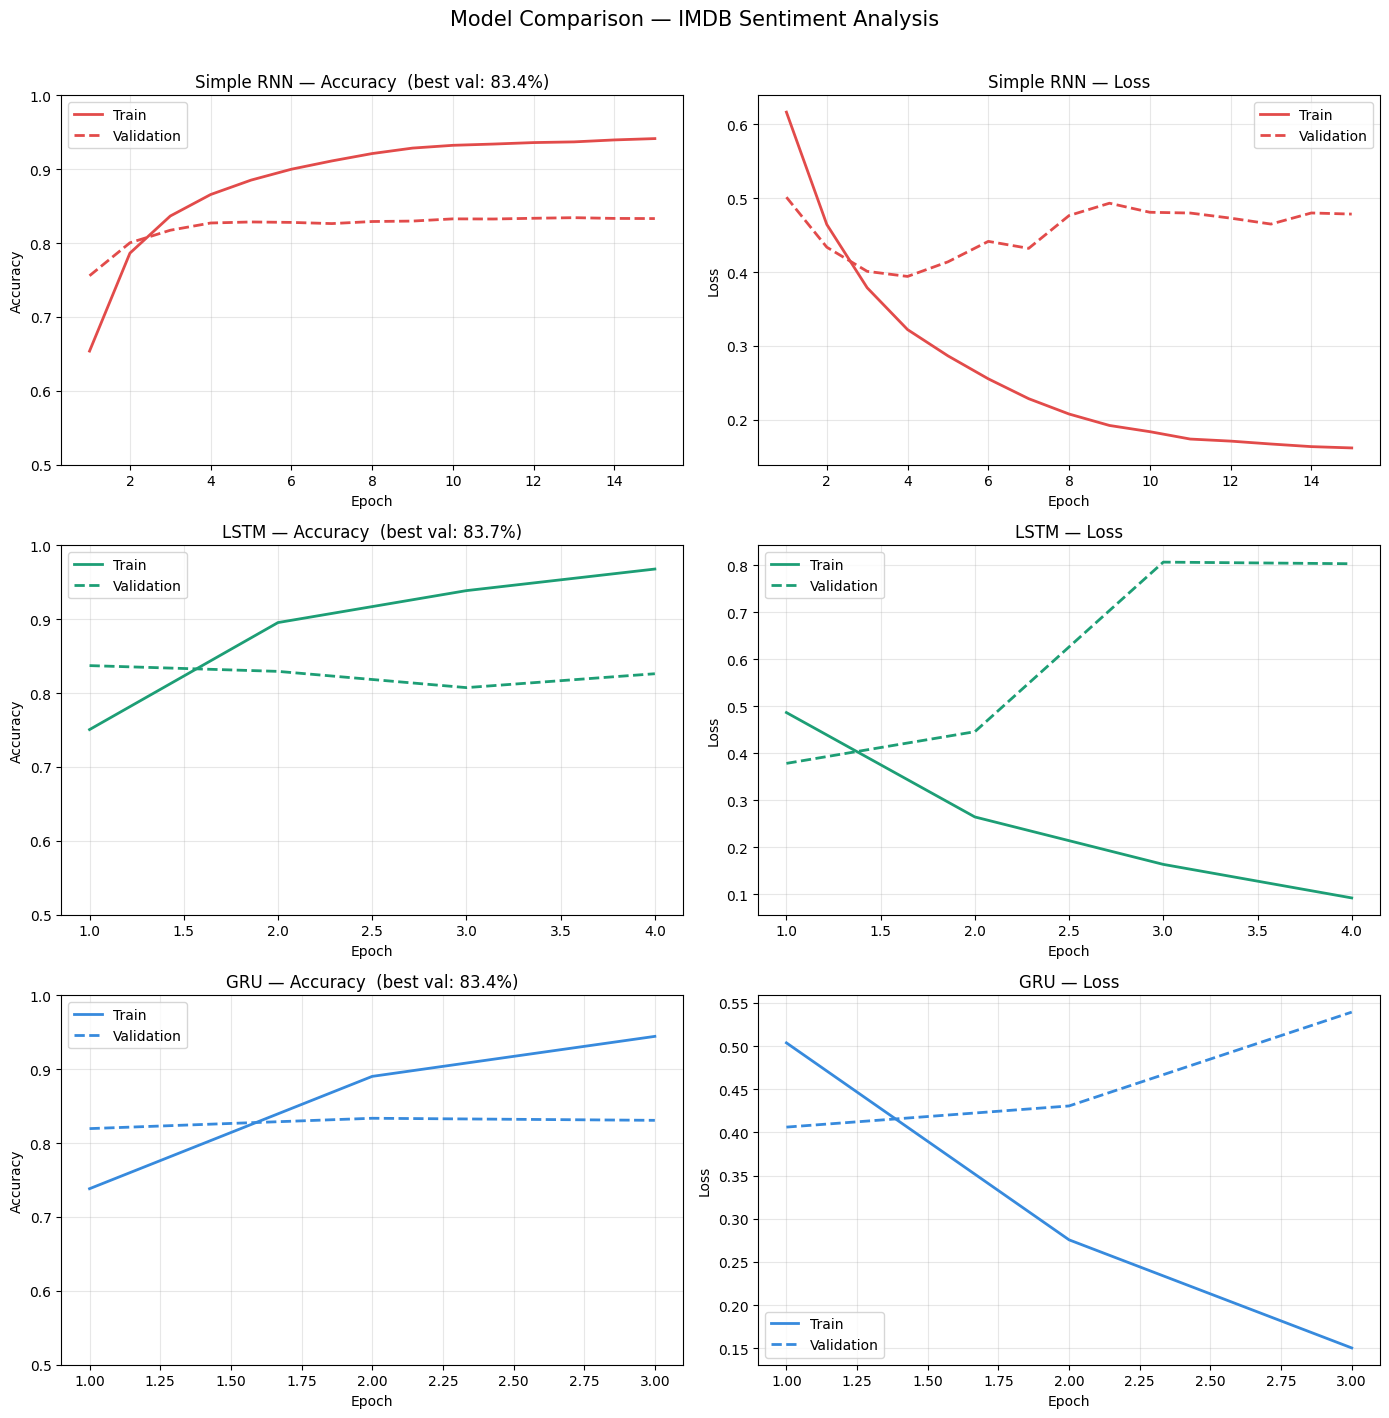

In [51]:
histories = {
    "Simple RNN": history_rnn,
    "LSTM":       history_lstm,
    "GRU":        history_gru,
}
colors = {"Simple RNN": "#E24B4A", "LSTM": "#1D9E75", "GRU": "#378ADD"}

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

for i, (name, history) in enumerate(histories.items()):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs   = range(1, len(acc) + 1)
    c        = colors[name]

    # Accuracy subplot
    axes[i, 0].plot(epochs, acc,    color=c, linewidth=2, label='Train')
    axes[i, 0].plot(epochs, val_acc, color=c, linewidth=2, linestyle='--', label='Validation')
    best = max(val_acc)
    axes[i, 0].set_title(f'{name} — Accuracy  (best val: {best*100:.1f}%)', fontsize=12)
    axes[i, 0].set_xlabel('Epoch'); axes[i, 0].set_ylabel('Accuracy')
    axes[i, 0].set_ylim([0.5, 1.0]); axes[i, 0].legend(); axes[i, 0].grid(alpha=0.3)

    # Loss subplot
    axes[i, 1].plot(epochs, loss,    color=c, linewidth=2, label='Train')
    axes[i, 1].plot(epochs, val_loss, color=c, linewidth=2, linestyle='--', label='Validation')
    axes[i, 1].set_title(f'{name} — Loss', fontsize=12)
    axes[i, 1].set_xlabel('Epoch'); axes[i, 1].set_ylabel('Loss')
    axes[i, 1].legend(); axes[i, 1].grid(alpha=0.3)

plt.suptitle('Model Comparison — IMDB Sentiment Analysis', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [52]:
def evaluate_model(model, model_name):
    y_prob = model.predict(x_test_pad, verbose=0).reshape(-1)
    y_pred = (y_prob >= 0.5).astype(int)

    acc       = accuracy_score(y_test,  y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test,    y_pred)
    f1        = f1_score(y_test,        y_pred)
    cm        = confusion_matrix(y_test, y_pred)

    print(f"===== {model_name} Classification Report =====")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
    print("Confusion Matrix:")
    print(cm)

    return {"Model": model_name, "Accuracy": acc,
            "Precision": precision, "Recall": recall, "F1-score": f1}, y_prob, y_pred


results = []
rnn_result,  rnn_prob,  rnn_pred  = evaluate_model(simple_rnn_model, "Simple RNN")
lstm_result, lstm_prob, lstm_pred = evaluate_model(lstm_model,        "LSTM")
gru_result,  gru_prob,  gru_pred  = evaluate_model(gru_model,         "GRU")

results.extend([rnn_result, lstm_result, gru_result])
results_df = pd.DataFrame(results)
results_df


===== Simple RNN Classification Report =====
              precision    recall  f1-score   support

    Negative       0.79      0.83      0.81     12500
    Positive       0.82      0.78      0.80     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000

Confusion Matrix:
[[10319  2181]
 [ 2752  9748]]
===== LSTM Classification Report =====
              precision    recall  f1-score   support

    Negative       0.78      0.87      0.82     12500
    Positive       0.85      0.75      0.80     12500

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.81     25000
weighted avg       0.81      0.81      0.81     25000

Confusion Matrix:
[[10827  1673]
 [ 3091  9409]]
===== GRU Classification Report =====
              precision    recall  f1-score   support

    Negative       0.75      0.88      0.81     12500
    Positive     

,Model,Accuracy,Precision,Recall,F1-score
0,Simple RNN,0.80268,0.817168,0.77984,0.798068
1,LSTM,0.80944,0.849034,0.75272,0.797982
2,GRU,0.79608,0.854910,0.71320,0.777652


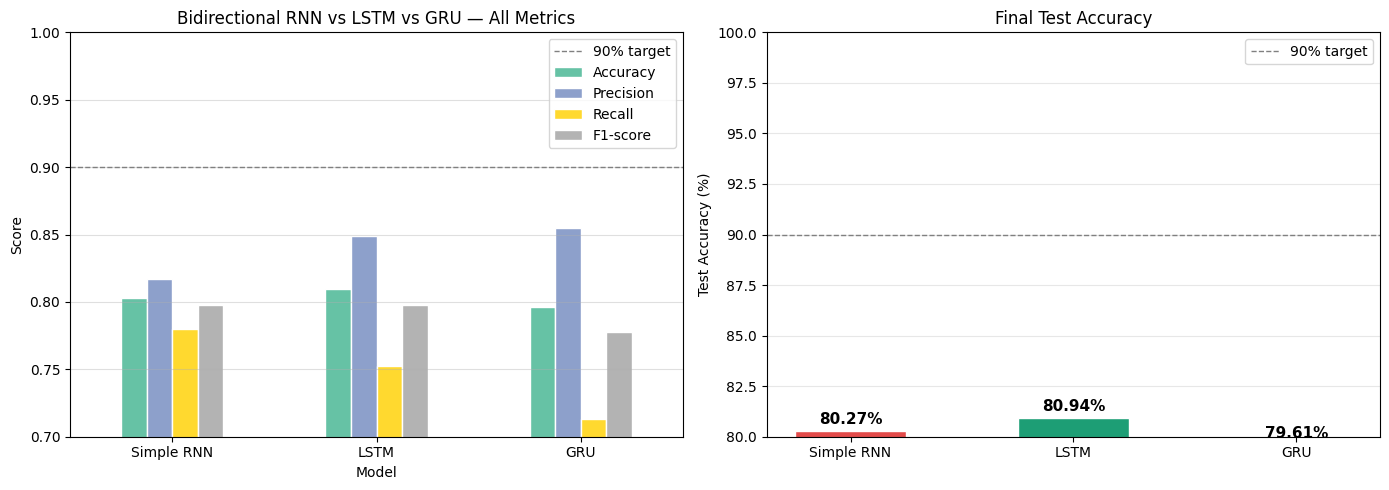

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: grouped metrics bar
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1-score']].plot(
    kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Bidirectional RNN vs LSTM vs GRU — All Metrics')
axes[0].set_ylabel('Score'); axes[0].set_ylim(0.7, 1.0)
axes[0].set_xticklabels(results_df['Model'], rotation=0)
axes[0].axhline(0.9, color='gray', linestyle='--', linewidth=1, label='90% target')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.4)

# Right: accuracy-only with value labels
bar_colors = ['#E24B4A', '#1D9E75', '#378ADD']
bars = axes[1].bar(results_df['Model'], results_df['Accuracy']*100,
                   color=bar_colors, width=0.5, edgecolor='white')
axes[1].set_ylim(80, 100); axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Final Test Accuracy')
axes[1].axhline(90, color='gray', linestyle='--', linewidth=1, label='90% target')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [54]:
best_row       = results_df.sort_values(by='F1-score', ascending=False).iloc[0]
best_model_name = best_row['Model']

if best_model_name == 'Simple RNN':
    best_model = simple_rnn_model; best_pred = rnn_pred;  best_prob = rnn_prob
elif best_model_name == 'LSTM':
    best_model = lstm_model;       best_pred = lstm_pred; best_prob = lstm_prob
else:
    best_model = gru_model;        best_pred = gru_pred;  best_prob = gru_prob

print("Best model based on F1-score:", best_model_name)
best_row


Best model based on F1-score: Simple RNN


,0
Model,Simple RNN
Accuracy,0.80268
Precision,0.817168
Recall,0.77984
F1-score,0.798068


## 6. Correct vs Wrong Prediction Examples


In [55]:
correct_indices = np.where(best_pred == y_test)[0]
wrong_indices   = np.where(best_pred != y_test)[0]


def sentiment_label(label):
    return "Positive" if label == 1 else "Negative"


def show_prediction_examples(indices, title, n=3):
    print(f"================ {title} ================")
    for idx in indices[:n]:
        review_text     = decode_review(x_test[idx])
        true_label      = sentiment_label(y_test[idx])
        predicted_label = sentiment_label(best_pred[idx])
        confidence      = best_prob[idx]

        print(f"Review index: {idx}")
        print("True label:",      true_label)
        print("Predicted label:", predicted_label)
        print("Positive probability:", round(float(confidence), 4))
        print("Review text:", review_text[:700], "...")


show_prediction_examples(correct_indices, "Correct Predictions", n=3)
show_prediction_examples(wrong_indices,   "Wrong Predictions",   n=3)


================ Correct Predictions ================
Review index: 0
True label: Negative
Predicted label: Negative
Positive probability: 0.0103
Review text: <START> please give this one a miss br br kristy swanson and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite lacklustre so all you madison fans give this a miss ...
Review index: 1
True label: Positive
Predicted label: Positive
Positive probability: 0.9818
Review text: <START> this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of the scenes take place on the same set in frances austen's the sandy dennis character apartment but the film builds to a disturbing climax br br the characters create an atmosphere rife with sexual tension and psychological trickery it's very

## 7. Prediction Demo


In [56]:
keras_word_index = imdb.get_word_index()

def encode_custom_review(text):
    words   = text.lower().split()
    encoded = [1]   # <START>
    for word in words:
        idx = keras_word_index.get(word)
        if idx is not None and idx + 3 < MAX_FEATURES:
            encoded.append(idx + 3)
        else:
            encoded.append(2)   # <UNK>
    return pad_sequences([encoded], maxlen=MAX_LEN, padding='post', truncating='post')


def predict_sentiment(review_text):
    encoded_review = encode_custom_review(review_text)
    prob      = float(best_model.predict(encoded_review, verbose=0)[0][0])
    sentiment = "Positive" if prob >= 0.5 else "Negative"
    print("Review:",               review_text)
    print("Predicted sentiment:",  sentiment)
    print("Positive probability:", round(prob, 4))
    return sentiment, prob

# Try your own reviews here:
predict_sentiment("The movie was amazing, emotional, and beautifully acted. I really enjoyed it.")
predict_sentiment("This film was boring, too long, and the acting was terrible.")


Review: The movie was amazing, emotional, and beautifully acted. I really enjoyed it.
Predicted sentiment: Positive
Positive probability: 0.9377
Review: This film was boring, too long, and the acting was terrible.
Predicted sentiment: Negative
Positive probability: 0.0972


('Negative', 0.09717965871095657)

# Final Report

## Introduction

This project builds a sentiment analysis system that classifies IMDb movie reviews into **positive** or **negative** classes. Sentiment analysis is an important Natural Language Processing task used in review analysis, social media monitoring, customer feedback analysis, and recommendation systems.

The dataset contains 50,000 labeled movie reviews and is balanced between positive and negative classes. The dataset is already split into training and testing sets.

## Dataset

The IMDb dataset contains:

- 25,000 training reviews
- 25,000 testing reviews
- Binary labels: positive or negative
- Text reviews encoded as sequences of word IDs

## Preprocessing

The preprocessing steps were:

1. Load the IMDb dataset using Keras.
2. Keep the top 10,000 most frequent words.
3. Convert all reviews to the same length using padding and truncation.
4. Use a maximum review length of 200 tokens.

Padding is necessary because deep learning models need fixed-size input batches.

## Models Implemented

### 1. Simple RNN

Simple RNN processes the review word by word and updates its hidden state. It is simple and fast, but it often struggles with long reviews because it may forget earlier words.

### 2. LSTM

LSTM is designed to solve the long-term dependency problem. It uses gates to decide what information to keep, forget, and output. This usually makes LSTM stronger than Simple RNN for text classification.

### 3. GRU

GRU is similar to LSTM but has a simpler structure. It has fewer gates, so it can be faster while still remembering important sequence information.

## Evaluation Metrics

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Classification report

Accuracy shows overall correctness, while F1-score is useful because it balances precision and recall.

## Analysis

Usually, Simple RNN performs the weakest because it has difficulty remembering long-term context. LSTM and GRU usually perform better because they use gating mechanisms that preserve important information across longer sequences.

The best model should be selected based on the test F1-score and accuracy shown in the evaluation table. In many sentiment analysis tasks, GRU can perform close to LSTM while training faster. LSTM may perform slightly better if long-term context is very important.

## Correct vs Wrong Predictions

Correct predictions usually happen when the review uses clear emotional words such as **amazing**, **excellent**, **boring**, or **terrible**.

Wrong predictions may happen when:

- The review contains sarcasm.
- The review is mixed, with both positive and negative opinions.
- The review uses rare words that are mapped to unknown tokens.
- The review is very long and important information is truncated.

## Conclusion

This project successfully implemented and compared three recurrent neural network models for IMDb sentiment analysis: Simple RNN, LSTM, and GRU.

The best model is automatically selected based on the F1-score. In general, LSTM and GRU are expected to outperform Simple RNN because they can handle longer text dependencies more effectively.

## How to Improve the Project Further

Possible improvements include:

1. Use bidirectional LSTM or bidirectional GRU.
2. Use pretrained word embeddings such as GloVe.
3. Try transformer-based models such as BERT.
4. Tune hyperparameters such as embedding size, recurrent units, dropout rate, and learning rate.
5. Increase training epochs if the computer can handle it.
